Number Cross 2
--
    
<img src='https://www.janestreet.com/puzzles/number_crossword_2.png' width=600 align='center'/>





Fill the cells in this crossword with the digits 1 through 9 (no zeroes). Each clue in this crossword represents either the sum of the digits or the product of the digits in its corresponding answer — it’s up to you to decide which. The clue could potentially represent both the sum and the product, if the sum and product are the same. Digits can be repeated within an answer, and answers can be repeated in the grid.

As your answer, submit the sum of all of the digits you entered into the completed grid.


In [1]:
import time
import itertools
import numpy as np
from z3 import *
from sympy.ntheory import factorint
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
shape = [
    1,1,1,1,0,1,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,0,1,1,0,1,1,1,0,1,1,0,0,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,1,1,1,1,0,1,1,1,1
]

shape = np.array(shape).reshape(9,9)

a_idx = [1,5,9,10,11,13,14,16,17,18,20,22,24,25,27,29,30]
d_idx = [1,14,22,2,23,3,20,4,26,12,5,15,6,21,7,18,8,19,28]

a_tar = [9,35,10,30,7,10,42,21,25,15,120,25,35,21,9,5,8]
d_tar = [45,18,70,20,12,48,30,72,2,12,18,32,24,12,27,45,26,20,36]


def _cellgroups(shape: np.array, rev = False) -> list[list[tuple]]:
    l = []
    temp = []
    
    for row, lst in enumerate(shape):
        if temp:
            l.append(temp)
            
        temp = []
        for col, cell in enumerate(lst):
            if cell != 0:
                if rev:
                    temp.append((col, row))

                else:
                    temp.append((row, col))
    
            elif temp:
                l.append(temp)
                temp = []
    if temp:
        l.append(temp)
        
    return l

a = _cellgroups(shape)
b = _cellgroups(shape.T, rev=True)

In [3]:
def dig2num(word):
    l = len(word)
    return Sum([num * 10 ** (l - i - 1) for i, num in enumerate(word)])

def digsum(word):
    return Sum([digit for digit in word])

def _findFactors(n: int, length: int) -> list[int]:
    #Important to add these for cases where say the target is 3 and the length is 3, allows for 311, 113 and 131
    lst = [1] * (length - 1)

    [lst.append(i) for i in range(1,10) if n % i == 0]


    for k,v in factorint(n).items():
        if k < 10:
            while lst.count(k) != v:
                lst.append(k)
    
    x = list(set((itertools.permutations(lst, length))))
    
    x = [list(i) for i in x if np.prod(i) == n]

    x = [sum([num * 10 ** (length - i - 1) for i, num in enumerate(row)]) for row in x]
    
    return x

n = shape.shape[0]
grid = np.array([[Int(f"X_{[j,i]}") for i in range(n)] for j in range(n)])
s = Tactic("qffd").solver()

d = {}
for k, v in enumerate(a):
    d[f"a{a_idx[k]}"] = {'target': a_tar[k], 'cells': [grid[i][j] for i,j in a[k]]}

for k, v in enumerate(b):
    d[f"d{d_idx[k]}"] = {'target': d_tar[k], 'cells': [grid[i][j] for i,j in b[k]]}

#Zeroes in the black squares, 1-9 in the white squares
[[s.add(grid[j][i] == 0) if cell == 0 else s.add(grid[j][i] > 0, grid[j][i] < 10) for i, cell in enumerate(row)] for j, row in enumerate(shape)]

for k, v in d.items():
    factors = _findFactors(v['target'], len(v['cells']))
    s += Or([digsum(v['cells']) == v['target']] + [dig2num(v['cells']) == i for i in factors])

start = time.perf_counter()
if s.check() == sat:
    m = s.model()
    sol = np.array([[m[cell].as_long() for cell in row] for row in grid])
    print(sol)

end = time.perf_counter()
print(f"Time elapsed is {(end - start):.2f} seconds")

[[9 1 1 1 0 9 8 9 9]
 [5 1 2 1 0 9 9 3 9]
 [0 2 3 1 1 0 1 1 8]
 [6 9 8 8 1 4 6 0 0]
 [3 7 0 9 8 8 0 3 5]
 [0 0 5 1 1 1 2 3 4]
 [5 5 1 0 1 1 7 5 0]
 [7 6 6 2 0 1 1 1 9]
 [2 1 1 1 0 1 2 1 4]]
Time elapsed is 20.62 seconds


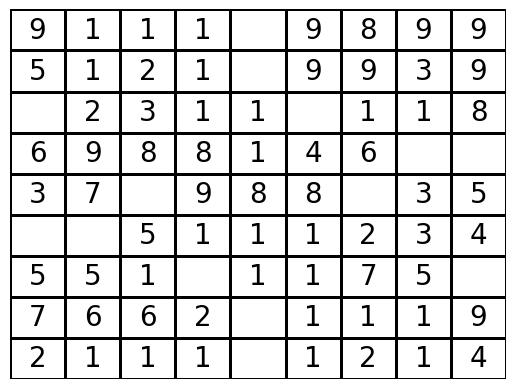

<Figure size 1000x1000 with 0 Axes>

Solution is 276


In [4]:
def grid_plotter(array: np.array) -> None:
    mask = array == 0
    ax = sns.heatmap(
        array, mask = mask, cmap=ListedColormap(['white']), annot=True, annot_kws={"fontsize":20, "color":"black"}, cbar=False, linewidths=1, linecolor="black",
        xticklabels = False, yticklabels = False
    )
    plt.figure(figsize = (10,10))
    plt.show()

grid_plotter(sol)
print(f"Solution is {sum(sol.flatten())}")